In [312]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [313]:
df= pd.read_csv("dataset.csv")
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    Male  28.880         0     no  northwest   3866.85520


In [314]:
# creating copy 
df_copy= df.copy()


In [315]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [316]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [317]:
df.shape

(1338, 7)

In [318]:
#checking null values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [319]:
#checcking unique values 
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

data visualisation


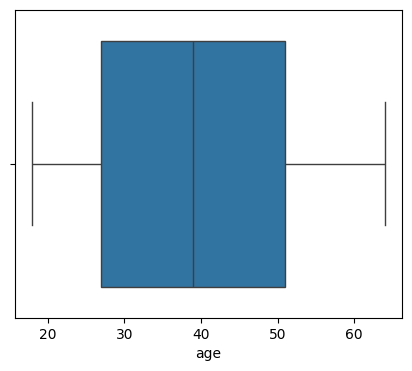

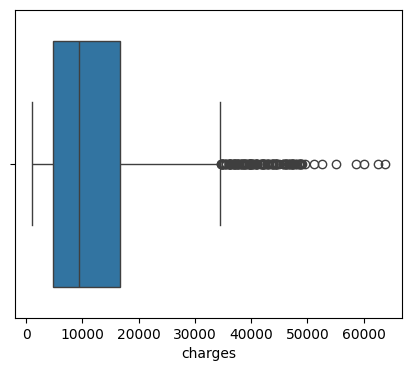

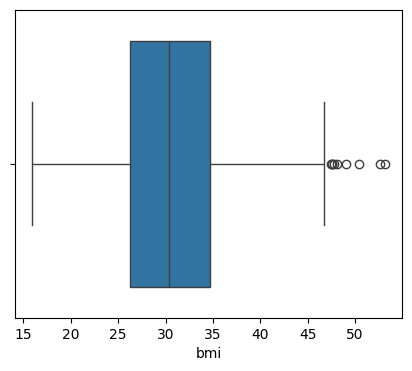

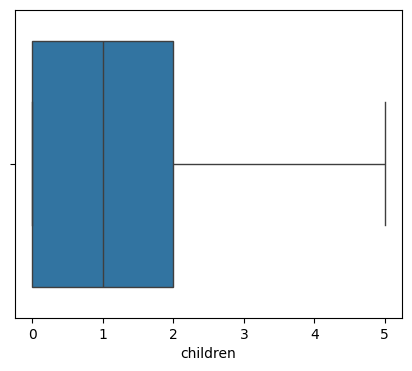

In [320]:
#graphs for numerical data
numeric_columns=["age","charges","bmi","children"]
for col in numeric_columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x= col )


plt.show()

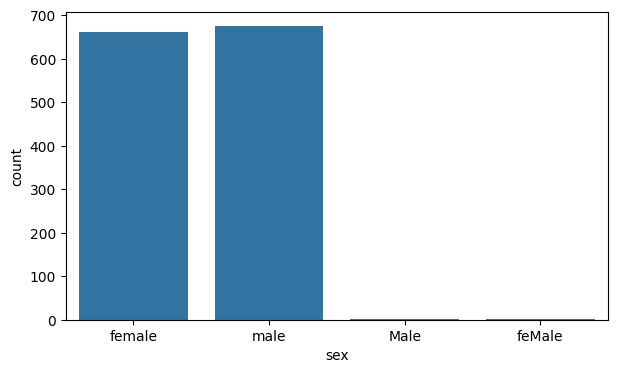

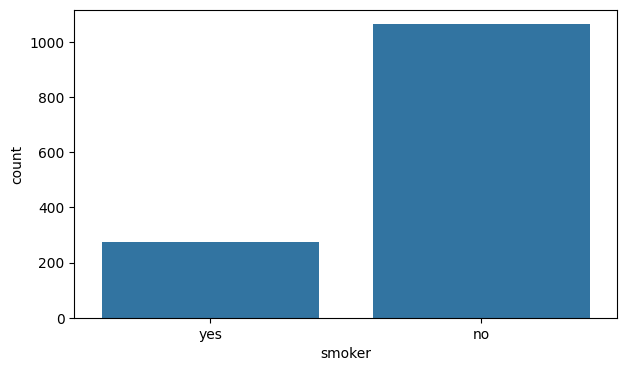

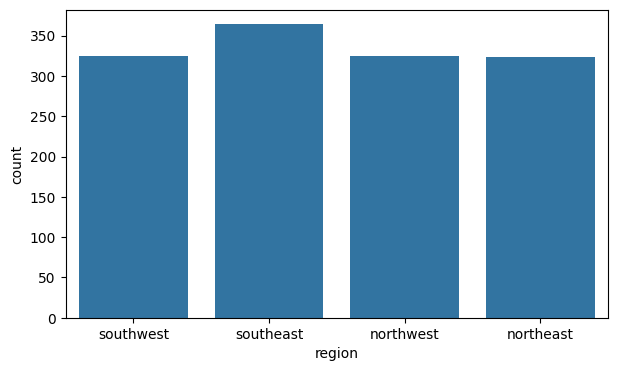

In [321]:
#graphs for categorical data
categorical_columns= ["sex","smoker","region"]
for i in categorical_columns:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df,x=i)
plt.show()

<Axes: >

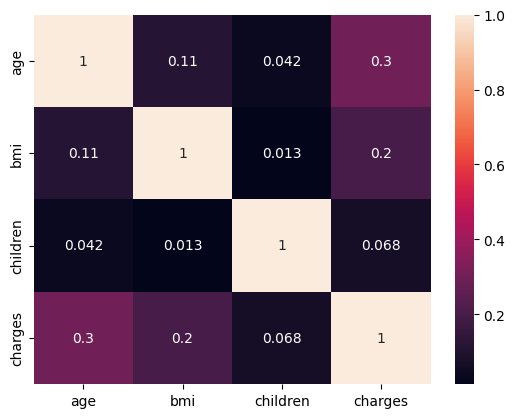

In [322]:
#now checking for relationship btw inputs and outputs, creating co related matrix
corelated_matrix=df.corr(numeric_only=True)

sns.heatmap(corelated_matrix,annot=True)

#now data preprocessing ()

In [323]:
for i in categorical_columns:
    print(df[i].unique())
df["sex"]=df["sex"].str.lower()


<StringArray>
['female', 'male', 'Male', 'feMale']
Length: 4, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [324]:
#removing duplicates
df.drop_duplicates()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


label encoding 


In [325]:
df["sex"]=df["sex"].map({"male":0, "female":1})
df["smoker"]=df["smoker"].map({"yes":1, "no":0})



one hot encoding


In [326]:
df=pd.get_dummies(df,columns=["region"]).astype(int)
df.head()


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


In [327]:
df.rename(columns={"sex":"is_female","smoker":"is_smoker"})

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


now standerisation


In [328]:
from sklearn.preprocessing import StandardScaler
obj= StandardScaler()
df[["age","bmi"]]=obj.fit_transform(df[["age","bmi"]])
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,1,-0.518122,0,1,16884,0,0,0,1
1,-1.509965,0,0.462657,1,0,1725,0,0,1,0
2,-0.797954,0,0.462657,3,0,4449,0,0,1,0
3,-0.441948,0,-1.335438,0,0,21984,0,1,0,0
4,-0.513149,0,-0.354659,0,0,3866,0,1,0,0


feature engneering

machine learning start

In [329]:
dict1={}
for i in df.columns: 
    dict1[i]=df["charges"].corr(df[i],method="spearman")
x= pd.DataFrame(list(dict1.items()), columns=["feature","relation"])
x.sort_values(by="relation",ascending=False)

,feature,relation
5,charges,1.000000
4,smoker,0.663460
0,age,0.534388
3,children,0.133341
2,bmi,0.118102
6,region_northeast,0.046118
8,region_southeast,0.017275
1,sex,-0.009492
7,region_northwest,-0.021652
9,region_southwest,-0.042345


In [330]:
#pearson co relation 
df["charges_bin"] = pd.qcut(df["charges"], q=4,labels=False)
chi2_results= {}
alpha=0.05
from scipy.stats import chi2_contingency
for col in df.columns:
    contingency= pd.crosstab(df[col],df["charges_bin"])
    chi2_stat, p_value, _,_ = chi2_contingency(contingency)
    decision= "keep feature" if p_value<alpha else "drop feature"
    chi2_results[col]= {
        "chi2_statistic": chi2_stat,
        "p_value": p_value,
        "decision": decision
    }

chi2_df= pd.DataFrame(chi2_results).T
chi2_df= chi2_df.sort_values(by="p_value")
print(chi2_df)


                 chi2_statistic   p_value      decision
charges_bin              4014.0       0.0  keep feature
age                 1521.204566       0.0  keep feature
smoker               854.020268       0.0  keep feature
children             139.565803       0.0  keep feature
region_southeast      15.208814  0.001647  keep feature
sex                    9.532132  0.022992  keep feature
bmi                  141.954092  0.025317  keep feature
charges                  4014.0  0.031305  keep feature
region_northeast       5.944573  0.114338  drop feature
region_southwest       5.530825  0.136807  drop feature
region_northwest       1.226112  0.746749  drop feature


In [332]:

df_final = df[['sex', 'bmi','age',  'children', 'smoker', 'region_southeast']]


Linear regression


In [336]:
from sklearn.model_selection import train_test_split
x= df_final
y= df["charges"]
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=20,random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
obj= LinearRegression()
obj.fit(x_train,y_train)


LinearRegression()


In [ ]:
y_predict= obj.predict(x_train)


1318
20
1318
20


In [349]:
from sklearn.metrics import r2_score
r2= r2_score(y_train,y_predict)
n= x_test.shape[0]
p= x_test.shape[1]
adjusted= 1- ((1-r2)* (n-1)/(n-p-1))
adjusted


0.6292164703451586